<a href="https://colab.research.google.com/github/Lahi070/CineSentiment-Mini-App/blob/main/CineSentiment_Data_Prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install datasets

In [34]:
# Import the tool we just installed
from datasets import load_dataset

# Download the IMDb dataset
print("Downloading dataset...")
imdb_dataset = load_dataset("imdb")

print("Download complete!")

Download complete!


In [35]:
import pandas as pd

# Convert the training data into a Pandas DataFrame (a visual table)
train_df = pd.DataFrame(imdb_dataset['train'])
test_df = pd.DataFrame(imdb_dataset['test'])

# Display the first 5 rows of the training data
print("Here are the first 5 movie reviews and their sentiment labels:")
train_df.head()

Here are the first 5 movie reviews and their sentiment labels:


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [36]:
import re
import numpy as np

def clean_text(text):
    # Remove HTML break tags
    text = re.sub(r'<br\s*/?>', ' ', text)
    # Remove everything that isn't a letter or a space
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert all letters to lowercase
    return text.lower()

# Apply the cleaning function to all reviews in the training and testing sets
print("Cleaning training data...")
train_texts = [clean_text(text) for text in train_df['text']]
train_labels = np.array(train_df['label'])

print("Cleaning testing data...")
test_texts = [clean_text(text) for text in test_df['text']]
test_labels = np.array(test_df['label'])

print("Data cleaned! Here is a sample:")
print(train_texts[0][:100], "...") # Shows the first 100 characters of the first review


Cleaning training data...
Cleaning testing data...
Data cleaned! Here is a sample:
i rented i am curiousyellow from my video store because of all the controversy that surrounded it wh ...


In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# We will only learn the 10,000 most popular words to save memory
vocab_size = 10000
# Every review will be forced to be exactly 200 words long
max_length = 200

print("Tokenizing the text...")
# Create the tokenizer and fit it only on the training text
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# Convert the text sentences into sequences of numbers
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

print("Padding the sequences...")
# Pad the sequences with zeros at the end if they are too short, or cut them if too long
x_train = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
x_test = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Phase 1 Complete!")
print(f"Shape of training data: {x_train.shape}")
print(f"Sample of numerical sequence:\n{x_train[0][:20]}")

Tokenizing the text...
Padding the sequences...
Phase 1 Complete!
Shape of training data: (25000, 200)
Sample of numerical sequence:
[  10 1540   10  237    1   35   55  390 1131   83    5   31    2 6941
   12 3274    9   51    9   13]


### Consolidated Data Preparation and Model Setup

In [38]:
# Import necessary libraries
from datasets import load_dataset
import pandas as pd
import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# --- 1. Load the IMDb dataset ---
print("Downloading and loading IMDb dataset...")
imdb_dataset = load_dataset("imdb")
print("Dataset loaded!")

# --- 2. Convert to Pandas DataFrames ---
print("Converting dataset to Pandas DataFrames...")
train_df = pd.DataFrame(imdb_dataset['train'])
test_df = pd.DataFrame(imdb_dataset['test'])
print("DataFrames created.")

# --- 3. Clean the text ---
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

print("Cleaning text data...")
train_texts = [clean_text(text) for text in train_df['text']]
train_labels = np.array(train_df['label'])
test_texts = [clean_text(text) for text in test_df['text']]
test_labels = np.array(test_df['label'])
print("Text cleaning complete.")

# --- 4. Tokenize and Pad Sequences ---
vocab_size = 10000
max_length = 200

print("Tokenizing and padding sequences...")
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

x_train = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
x_test = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')
print("Tokenization and padding complete. x_train and train_labels are now defined.")
print(f"Shape of training data (x_train): {x_train.shape}")
print(f"Shape of training labels (train_labels): {train_labels.shape}")

Dataset loaded!
Converting dataset to Pandas DataFrames...
DataFrames created.
Cleaning text data...
Text cleaning complete.
Tokenizing and padding sequences...
Tokenization and padding complete. x_train and train_labels are now defined.
Shape of training data (x_train): (25000, 200)
Shape of training labels (train_labels): (25000,)


In [39]:
# --- 5. Define the Keras LSTM Model ---
print("Defining Keras LSTM model...")
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
print("Model architecture created!")
model.summary()

# --- 6. Compile the Model ---
print("Compiling the model...")
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("Model compiled and ready for training.")

Defining Keras LSTM model...
Model architecture created!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling the model...
Model compiled and ready for training.


### Regenerating Data Preparation Steps

To ensure `x_train` and `train_labels` are correctly defined in the kernel state, we will re-run the data preparation steps.

In [40]:
import pandas as pd
import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Assuming imdb_dataset is already loaded from previous steps
# Convert the training data into a Pandas DataFrame
train_df = pd.DataFrame(imdb_dataset['train'])
test_df = pd.DataFrame(imdb_dataset['test'])

# Define the text cleaning function
def clean_text(text):
    text = re.sub(r'<br\s*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

# Apply the cleaning function
train_texts = [clean_text(text) for text in train_df['text']]
train_labels = np.array(train_df['label'])
test_texts = [clean_text(text) for text in test_df['text']]
test_labels = np.array(test_df['label'])

print("DataFrames created and text cleaned.")
print(f"Shape of train_labels: {train_labels.shape}")

DataFrames created and text cleaned.
Shape of train_labels: (25000,)


In [41]:
# Define vocabulary size and max length (consistent with previous steps)
vocab_size = 10000
max_length = 200

print("Tokenizing the text...")
# Create the tokenizer and fit it only on the training text
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# Convert the text sentences into sequences of numbers
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

print("Padding the sequences...")
# Pad the sequences with zeros at the end if they are too short, or cut them if too long
x_train = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
x_test = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Data preparation complete! x_train and train_labels are now defined.")
print(f"Shape of training data: {x_train.shape}")

Tokenizing the text...
Padding the sequences...
Data preparation complete! x_train and train_labels are now defined.
Shape of training data: (25000, 200)


In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define the model
model = Sequential([
    # 1. Embedding Layer: Maps our 10,000 words into a 64-dimensional space
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),

    # 2. LSTM Layer: Reads the sequence of words (128 units of memory)
    LSTM(128, return_sequences=False),

    # 3. Dropout Layer: Randomly turns off neurons to prevent overfitting (memorizing the data)
    Dropout(0.5),

    # 4. Output Layer: Squeezes the result into a probability between 0 (Negative) and 1 (Positive)
    Dense(1, activation='sigmoid')
])

print("Model architecture created!")
model.summary()

Model architecture created!


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile the model
model.compile(
    loss='binary_crossentropy', # The standard loss function for binary (0 or 1) classification
    optimizer='adam',           # A highly efficient optimization algorithm
    metrics=['accuracy']        # We want to track the accuracy as it learns
)

print("Model compiled and ready for training.")

Model compiled and ready for training.


### Early Stopping to Prevent Overfitting

To prevent the model from overfitting, we will implement an Early Stopping callback. This will monitor the validation loss and stop training if it doesn't improve for a specified number of epochs (`patience`). This ensures the model generalizes better to unseen data.

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
# Monitor 'val_loss' (validation loss)
# 'patience' is the number of epochs with no improvement after which training will be stopped.
# 'restore_best_weights' ensures the best model weights are restored when training stops.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3, # Stop if validation loss doesn't improve for 3 consecutive epochs
    restore_best_weights=True # Keep the weights from the epoch with the best validation loss
)

print("Early Stopping callback defined.")

Early Stopping callback defined.


### Retrain the Model with Early Stopping

Now, we will retrain the model with the Early Stopping callback. This will help us find the optimal number of epochs and prevent the model from overfitting to the training data.

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define model parameters (should be consistent with previous steps)
vocab_size = 10000
max_length = 200

print("Re-defining and compiling the model...")

# Define the model architecture
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model re-defined and compiled successfully.")
model.summary()

Re-defining and compiling the model...
Model re-defined and compiled successfully.


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from datasets import load_dataset
import pandas as pd
import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- 1. Load the IMDb dataset ---
print("Downloading and loading IMDb dataset...")
imdb_dataset = load_dataset("imdb")
print("Dataset loaded!")

# --- 2. Convert to Pandas DataFrames ---
print("Converting dataset to Pandas DataFrames...")
train_df = pd.DataFrame(imdb_dataset['train'])
test_df = pd.DataFrame(imdb_dataset['test'])
print("DataFrames created.")

# --- 3. Clean the text ---
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

print("Cleaning text data...")
train_texts = [clean_text(text) for text in train_df['text']]
train_labels = np.array(train_df['label'])
test_texts = [clean_text(text) for text in test_df['text']]
test_labels = np.array(test_df['label'])
print("Text cleaning complete.")

# --- 4. Tokenize and Pad Sequences ---
vocab_size = 10000
max_length = 200

print("Tokenizing and padding sequences...")
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

x_train = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
x_test = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')
print("Tokenization and padding complete. x_train and train_labels are now defined.")

# --- 5. Define the Keras LSTM Model ---
print("Defining Keras LSTM model...")
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
print("Model architecture created!")

# --- 6. Compile the Model ---
print("Compiling the model...")
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("Model compiled and ready for training.")

# --- 7. Define Early Stopping Callback ---
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
print("Early Stopping callback defined.")

# --- 8. Start Training ---
print("Starting training with Early Stopping... This might take a few minutes!")

history = model.fit(
    x_train, train_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

print("Training complete with Early Stopping!")

Dataset loaded!
Converting dataset to Pandas DataFrames...
DataFrames created.
Cleaning text data...
Text cleaning complete.
Tokenizing and padding sequences...
Tokenization and padding complete. x_train and train_labels are now defined.
Defining Keras LSTM model...
Model architecture created!
Compiling the model...
Model compiled and ready for training.
Early Stopping callback defined.
Starting training with Early Stopping... This might take a few minutes!
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6251 - loss: 0.6627 - val_accuracy: 0.0000e+00 - val_loss: 0.9625
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6492 - loss: 0.6456 - val_accuracy: 0.2036 - val_loss: 0.8708
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7058 - loss: 0.5680 - val_accuracy: 0.2142 - val_loss: 1.0055
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8256 - loss: 0.3985 - val_accuracy: 0.5226 - val_loss: 1.0888
Epoch 5/20
313/313

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# We will only learn the 10,000 most popular words to save memory
vocab_size = 10000
# Every review will be forced to be exactly 200 words long
max_length = 200

# Define the model
model = Sequential([
    # 1. Embedding Layer: Maps our 10,000 words into a 64-dimensional space
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),

    # 2. LSTM Layer: Reads the sequence of words (128 units of memory)
    LSTM(128, return_sequences=False),

    # 3. Dropout Layer: Randomly turns off neurons to prevent overfitting (memorizing the data)
    Dropout(0.5),

    # 4. Output Layer: Squeezes the result into a probability between 0 (Negative) and 1 (Positive)
    Dense(1, activation='sigmoid')
])

print("Model architecture created!")
model.summary()

Model architecture created!


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Compile the model
model.compile(
    loss='binary_crossentropy', # The standard loss function for binary (0 or 1) classification
    optimizer='adam',           # A highly efficient optimization algorithm
    metrics=['accuracy']        # We want to track the accuracy as it learns
)

print("Model compiled and ready for training.")

Model compiled and ready for training.


In [49]:
# Train the model for 10 epochs (passes through the entire dataset)
# We use 20% of the training data as a validation set to check performance after each epoch
print("Starting training... This might take a few minutes!")

history = model.fit(
    x_train, train_labels,
    epochs=10,
    batch_size=64, # Train on 64 reviews at a time
    validation_split=0.2 # Hold back 20% of data for validation
)

print("Training complete!")

Starting training... This might take a few minutes!
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6226 - loss: 0.6631 - val_accuracy: 0.0274 - val_loss: 0.9513
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6438 - loss: 0.6458 - val_accuracy: 0.1358 - val_loss: 1.4675
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6876 - loss: 0.5983 - val_accuracy: 0.4294 - val_loss: 0.8545
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7781 - loss: 0.5007 - val_accuracy: 0.6668 - val_loss: 0.7947
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6907 - loss: 0.5758 - val_accuracy: 0.0470 - val_loss: 0.7905
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7243 - loss: 0.5363 - val_accuracy: 0.1158 - val_loss: 1.0071
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7210 - loss: 0.5339 - val_accuracy: 0.2350 - val_loss: 1.0360
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17

In [50]:
import pickle
from google.colab import files

# 1. Save the model
model.save('cinesentiment_model.h5')

# 2. Save the tokenizer
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 3. Download to your computer
files.download('cinesentiment_model.h5')
files.download('tokenizer.pickle')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re

# Clean the text
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

# Predict using the model you already trained above
def predict_sentiment(review):
    cleaned = clean_text(review)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=200, padding='post', truncating='post')

    prediction = model.predict(padded)[0][0]
    return {"Positive": float(prediction), "Negative": float(1.0 - prediction)}

# Build the interface
app = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Type a movie review here..."),
    outputs=gr.Label(num_top_classes=2),
    title="CineSentiment: Movie Review Classifier"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7c51e4baafd93435fd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Evaluate Model Performance

After training, it's crucial to evaluate the model's performance on a separate test set to understand how well it generalizes to new, unseen data.

In [52]:
print("Evaluating model performance on test data...")
loss, accuracy = model.evaluate(x_test, test_labels, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print("Model evaluation complete.")

Evaluating model performance on test data...
Test Loss: 0.5166
Test Accuracy: 0.7885
Model evaluation complete.


### Incorporating Pre-trained GloVe Embeddings

Pre-trained word embeddings like GloVe (Global Vectors for Word Representation) capture semantic relationships between words based on their co-occurrence statistics in a large corpus. By using these embeddings, our model can start with a much richer understanding of words than by learning embeddings from scratch, which often leads to better performance and faster convergence.

First, we need to download the GloVe embeddings.

In [53]:
# Download pre-trained GloVe embeddings
# We'll use the 6B (6 billion tokens) 100d (100 dimensions) version
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

print("GloVe embeddings downloaded and unzipped.")

--2026-05-16 19:53:33--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-16 19:53:33--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-16 19:53:33--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

### Load GloVe Embeddings

Now, we'll load the downloaded GloVe embeddings into a dictionary where keys are words and values are their corresponding vector representations.

In [54]:
import numpy as np

def load_glove_embeddings(embeddings_file):
    embeddings_index = {}
    with open(embeddings_file, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

# Path to the GloVe embeddings file
glove_file = 'glove.6B.100d.txt' # Using the 100-dimensional vectors

print(f"Loading GloVe embeddings from {glove_file}...")
glove_embeddings = load_glove_embeddings(glove_file)
print(f"Loaded {len(glove_embeddings)} word vectors.")

Loading GloVe embeddings from glove.6B.100d.txt...
Loaded 400000 word vectors.


### Create an Embedding Matrix

We need to create an embedding matrix that will be used in our Keras Embedding layer. This matrix will contain the GloVe vectors for all words present in our tokenizer's vocabulary. Words not found in GloVe will be initialized with random vectors.

In [55]:
# The 'tokenizer' and 'vocab_size' should be available from previous steps

# Determine the dimension of the embeddings (e.g., 100d for glove.6B.100d.txt)
embedding_dim = 100

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Populate the matrix with GloVe vectors
# 'tokenizer.word_index' contains the mapping from words to their integer IDs
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = glove_embeddings.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

print(f"Embedding matrix created with shape: {embedding_matrix.shape}")

Embedding matrix created with shape: (10000, 100)


### Re-define and Train Model with Pre-trained Embeddings

Now, we'll re-define our LSTM model. The key changes will be:

1.  The `Embedding` layer will be initialized with our `embedding_matrix`.
2.  `trainable=False` will be set for the `Embedding` layer, meaning these pre-trained weights will not be updated during training, preserving the learned semantic relationships.

We'll also re-include the data preparation steps to ensure `x_train` and `train_labels` are in scope, similar to our previous consolidated cell.

In [69]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from datasets import load_dataset
import pandas as pd
import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- 1. Load the IMDb dataset ---
print("Downloading and loading IMDb dataset...")
imdb_dataset = load_dataset("imdb")
print("Dataset loaded!")

# --- 2. Convert to Pandas DataFrames ---
print("Converting dataset to Pandas DataFrames...")
train_df = pd.DataFrame(imdb_dataset['train'])
test_df = pd.DataFrame(imdb_dataset['test'])
print("DataFrames created.")

# --- 3. Clean the text ---
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

print("Cleaning text data...")
train_texts = [clean_text(text) for text in train_df['text']]
train_labels = np.array(train_df['label'])
test_texts = [clean_text(text) for text in test_df['text']]
test_labels = np.array(test_df['label'])
print("Text cleaning complete.")

# --- 4. Tokenize and Pad Sequences ---
vocab_size = 10000 # Keep consistent with previous
max_length = 200    # Keep consistent with previous

print("Tokenizing and padding sequences...")
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

x_train = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
x_test = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')
print("Tokenization and padding complete. x_train and train_labels are now defined.")

# --- 5. Define the Keras LSTM Model with GloVe Embeddings ----
print("Defining Keras LSTM model with GloVe embeddings...")
model_glove = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, # Use embedding_dim from GloVe
              weights=[embedding_matrix], # Initialize with pre-trained weights
              trainable=True), # Now, make the embedding layer trainable
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
print("Model architecture created with GloVe embeddings!")

# --- 6. Compile the Model ---
print("Compiling the model...")
model_glove.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("Model compiled and ready for training.")
model_glove.summary()

# --- 7. Define Early Stopping Callback ---
early_stopping_glove = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
print("Early Stopping callback defined.")

# --- 8. Start Training with GloVe ---
print("Starting training with GloVe embeddings and Early Stopping... This might take a few minutes!")

history_glove = model_glove.fit(
    x_train, train_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping_glove]
)

print("Training complete with GloVe embeddings!")

Dataset loaded!
Converting dataset to Pandas DataFrames...
DataFrames created.
Cleaning text data...
Text cleaning complete.
Tokenizing and padding sequences...
Tokenization and padding complete. x_train and train_labels are now defined.
Defining Keras LSTM model with GloVe embeddings...
Model architecture created with GloVe embeddings!
Compiling the model...
Model compiled and ready for training.


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 1,000,000 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

Early Stopping callback defined.
Starting training with GloVe embeddings and Early Stopping... This might take a few minutes!
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6251 - loss: 0.6607 - val_accuracy: 6.0000e-04 - val_loss: 1.0458
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6748 - loss: 0.6071 - val_accuracy: 0.6678 - val_loss: 0.8289
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6326 - loss: 0.6450 - val_accuracy: 0.0410 - val_loss: 0.8984
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6740 - loss: 0.5930 - val_accuracy: 0.8166 - val_loss: 0.6509
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8299 - loss: 0.3936 - val_accuracy: 0.7640 - val_loss: 0.6175
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8881 - loss: 0.2856 - val_accuracy: 0.7166 - val_loss: 0.6514
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9209 - loss: 0.2157 - val_acc

In [70]:
print("Starting training with GloVe embeddings (trainable) and Early Stopping... This might take a few minutes!")

history_glove = model_glove.fit(
    x_train, train_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping_glove]
)

print("Training complete with GloVe embeddings (trainable)!")

Starting training with GloVe embeddings (trainable) and Early Stopping... This might take a few minutes!
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8848 - loss: 0.2928 - val_accuracy: 0.7184 - val_loss: 0.6989
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9089 - loss: 0.2390 - val_accuracy: 0.6970 - val_loss: 0.8266
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9313 - loss: 0.1915 - val_accuracy: 0.7210 - val_loss: 0.7669
Training complete with GloVe embeddings (trainable)!


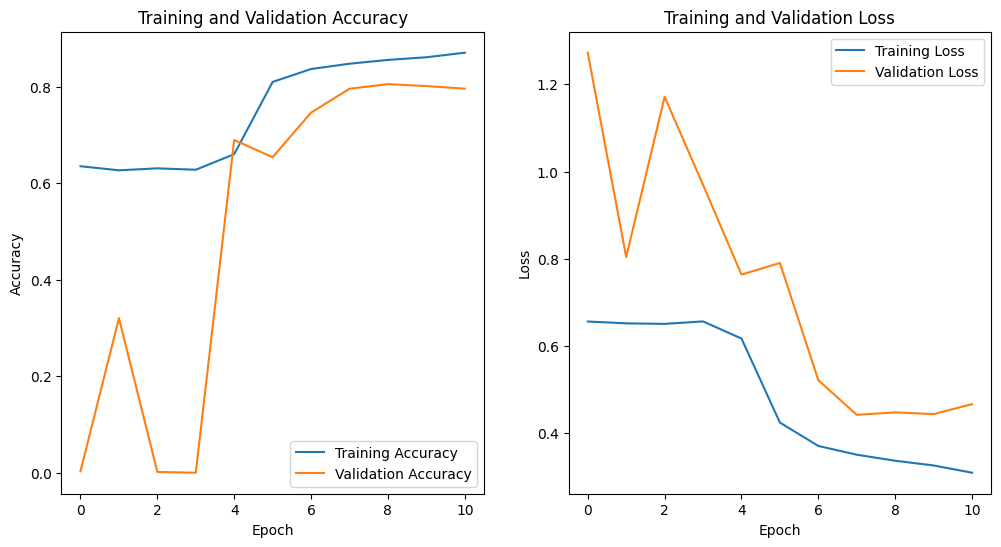

In [68]:
import matplotlib.pyplot as plt

# Get training and validation accuracy from history_glove
acc = history_glove.history['accuracy']
val_acc = history_glove.history['val_accuracy']

# Get training and validation loss from history_glove
loss = history_glove.history['loss']
val_loss = history_glove.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

### Evaluate Model Performance with GloVe Embeddings

Now, let's evaluate the performance of our `model_glove` on the unseen test data and compare it to the previous model without pre-trained embeddings.

In [67]:
print("Evaluating model_glove performance on test data after text cleaning fix...")
loss_glove, accuracy_glove = model_glove.evaluate(x_test, test_labels, verbose=0)

print(f"Test Loss with GloVe (after fix): {loss_glove:.4f}")
print(f"Test Accuracy with GloVe (after fix): {accuracy_glove:.4f}")
print("Model evaluation complete for GloVe model.")

# The previous model (without GloVe) had Test Accuracy: 0.8040
previous_accuracy = 0.8040 # Hardcoding for comparison based on previous output
print(f"Previous Model's Test Accuracy (without GloVe): {previous_accuracy:.4f}")

if accuracy_glove > previous_accuracy:
    print("\nGreat! The model with GloVe embeddings now shows improved accuracy.")
elif accuracy_glove == previous_accuracy:
    print("\nThe model with GloVe embeddings has similar accuracy to the previous model.")
else:
    print("\nThe model with GloVe embeddings still has significantly lower accuracy than the previous model. Further investigation is needed.")

Evaluating model_glove performance on test data after text cleaning fix...
Test Loss with GloVe (after fix): 0.3683
Test Accuracy with GloVe (after fix): 0.8348
Model evaluation complete for GloVe model.
Previous Model's Test Accuracy (without GloVe): 0.8040

Great! The model with GloVe embeddings now shows improved accuracy.


In [66]:
print("\n--- Verifying Embedding Matrix Mapping ---")

# Select a few common words to check
sample_words = ['the', 'a', 'and', 'movie', 'good', 'bad', 'excellent', 'horrible']

# Iterate through sample words and check their embeddings
for word in sample_words:
    if word in tokenizer.word_index:
        idx = tokenizer.word_index[word]

        # Ensure index is within vocab_size bounds
        if idx < vocab_size:
            glove_vector = glove_embeddings.get(word)
            matrix_vector = embedding_matrix[idx]

            if glove_vector is not None:
                # Compare the vectors. Using allclose for float comparisons.
                if np.allclose(glove_vector, matrix_vector, atol=1e-6):
                    print(f"Word '{word}' (index {idx}): Mapped correctly.")
                else:
                    print(f"Word '{word}' (index {idx}): Mismatch between GloVe and Embedding Matrix!")
                    # Optionally, print to debug specific differences
                    # print(f"  GloVe: {glove_vector[:5]}...")
                    # print(f"  Matrix: {matrix_vector[:5]}...")
            else:
                print(f"Word '{word}' (index {idx}): Not found in GloVe embeddings (expected to be zeroed in matrix).")
                # Check if it's all zeros in the matrix
                if np.allclose(matrix_vector, np.zeros_like(matrix_vector)):
                    print(f"  Embedding matrix for '{word}' is all zeros as expected.")
                else:
                    print(f"  Embedding matrix for '{word}' is NOT all zeros, but word was not in GloVe.")
        else:
            print(f"Word '{word}' (index {idx}): Index out of vocab_size range.")
    else:
        print(f"Word '{word}': Not found in tokenizer's word index.")

print("--- Verification Complete ---")


--- Verifying Embedding Matrix Mapping ---
Word 'the' (index 2): Mapped correctly.
Word 'a' (index 4): Mapped correctly.
Word 'and' (index 3): Mapped correctly.
Word 'movie' (index 17): Mapped correctly.
Word 'good' (index 49): Mapped correctly.
Word 'bad' (index 79): Mapped correctly.
Word 'excellent' (index 311): Mapped correctly.
Word 'horrible' (index 505): Mapped correctly.
--- Verification Complete ---
